In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

In [2]:
np.random.seed(0)
X = np.random.randn(100, 1) * 2
true_w, true_b = 3.0, 4.0
Y = true_w * X + true_b + np.random.randn(100, 1) * 0.5

In [3]:
w = np.random.randn(1, 1)
b = np.zeros((1, 1))
y_pred = X @ w + b

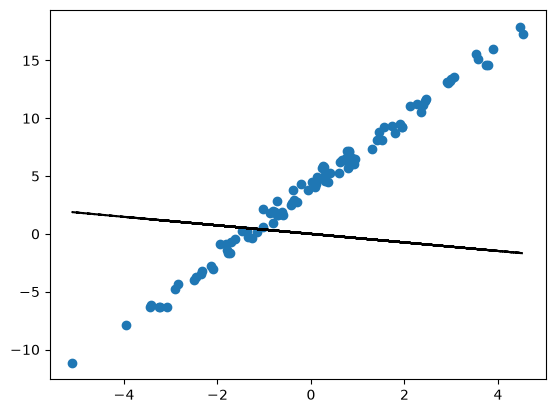

In [4]:
plt.scatter(X, Y)
plt.plot(X, y_pred, '--k')
plt.show()

In [5]:
def mse(y_pred, y):
    return np.mean((y_pred - y)**2)

In [6]:
def get_dw(error, X):
    return np.mean(2 * error * X)

def get_db(error):
    return np.mean(2 * error)

In [7]:
def train(X, Y, w, b, lr=0.1):
    loss_lst = []

    x_plot = np.asarray(X).flatten()
    y_actual = np.asarray(Y).flatten()
    sort_idx = np.argsort(x_plot)

    for epoch in range(250):
        # Forward pass
        y_pred = X @ w + b
        error = y_pred - Y

        # Loss
        loss = mse(y_pred, Y)
        loss_lst.append(loss)

        # Gradients
        dw = get_dw(error, X)
        db = get_db(error)

        # Update parameters
        w -= lr * dw
        b -= lr * db

        # Update plots every 10 epochs
        if epoch % 10 == 0 or epoch == 249:
            clear_output(wait=True)

            fig, (ax1, ax2) = plt.subplots(
                1, 2, figsize=(12, 5)
            )

            # Plot 1: MSE
            ax1.plot(loss_lst, color="blue")
            ax1.set_title(f"MSE | Epoch {epoch}")
            ax1.set_xlabel("Epoch")
            ax1.set_ylabel("Loss")
            ax1.set_xlim(0, 250)
            ax1.grid(True)

            # Plot 2: Regression
            ax2.scatter(
                x_plot, y_actual,
                color="blue", label="Actual"
            )

            updated_pred = np.asarray(X @ w + b).flatten()

            ax2.plot(
                x_plot[sort_idx],
                updated_pred[sort_idx],
                "--k",
                label="Prediction"
            )

            ax2.set_title("Linear Regression")
            ax2.set_xlabel("X")
            ax2.set_ylabel("Y")
            ax2.legend()
            ax2.grid(True)

            plt.tight_layout()
            display(fig)
            plt.close(fig)

            print(f"Epoch: {epoch}")
            print(f"Loss: {loss:.6f}")
            print(f"W: {w}")
            print(f"B: {b}")

    return w, b

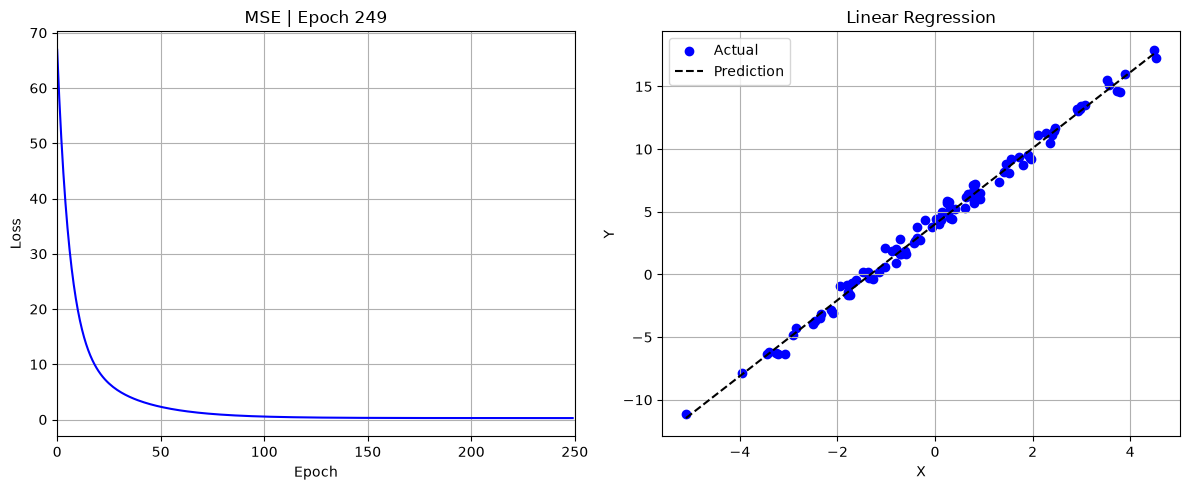

Epoch: 249
Loss: 0.264972
W: [[3.0296672]]
B: [[4.01199946]]


In [8]:
w, b = train(X, Y, w, b, 0.01)